In [ ]:
import pandas as pd
import treedata as td
import scanpy as sc
import pycea as py
import matplotlib.pyplot as plt
from pathlib import Path
plt.rcParams["figure.figsize"] = (4, 4)

/project/imoskowitz/yubin/envs/petracer/lib/python3.11/site-packages/treedata/_core/read.py:19: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  ANDATA_VERSION = version.parse(ad.__version__)
/project/imoskowitz/yubin/envs/petracer/lib/python3.11/site-packages/requests/__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [4]:
basePath = "/project/imoskowitz/yubin/Lineage_Tree_Construction/"
output_data = basePath + "output_data/"
output_plot = basePath + "output_plot/"
PEtracing_data = basePath +"PEtracing/Data/"

In [3]:
tdata = py.datasets.yang22()
tdata

Subsetting to tumors: 3435_NT_T1


TreeData object with n_obs × n_vars = 1109 × 2000
    obs: 'tumor', 'mouse', 'lane', 'fitness', 'plasticity', 'cluster', 'tree'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'priors'
    obsm: 'X_scVI', 'X_umap', 'characters'
    layers: 'counts'
    obst: '3435_NT_T1'

In [4]:
print(tdata.obst["3435_NT_T1"])

DiGraph with 1890 nodes and 1889 edges


### Plotting a tree

<Axes: >

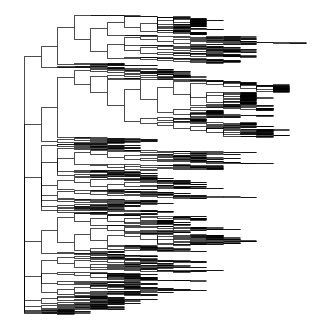

In [5]:
py.pl.branches(tdata)

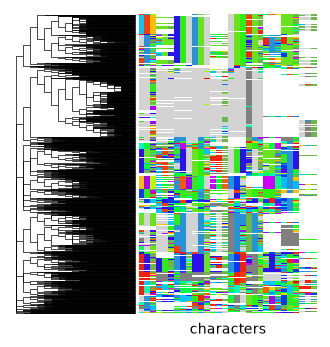

In [ ]:
indel_palette = py.get.palette(
    tdata,
    "characters",
    custom={"-": "white", "*": "lightgrey"},
    cmap="gist_rainbow",
    priors=tdata.uns["priors"],
    sort="random",
    random_state=0,
)
py.pl.branches(tdata, extend_branches=True)
py.pl.annotation(tdata, keys="characters", palette=indel_palette)

<PolarAxes: >

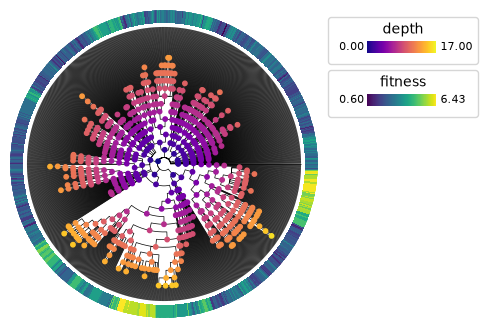

In [11]:
py.pl.branches(tdata, extend_branches=True, polar=True)
py.pl.nodes(tdata, color='depth', cmap="plasma")
py.pl.annotation(tdata, keys='fitness', cmap='viridis', width=.1)

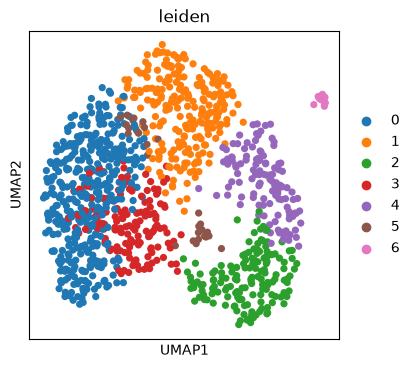

In [16]:
sc.tl.pca(tdata)
sc.pp.neighbors(tdata)
sc.tl.leiden(tdata, resolution=0.7, flavor="igraph")
sc.tl.umap(tdata)
sc.pl.umap(tdata, color="leiden")

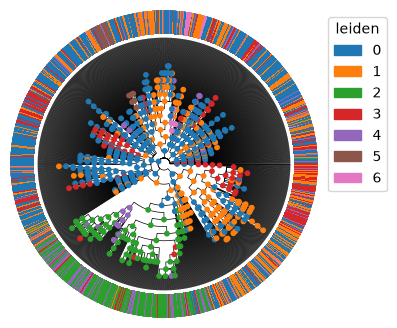

In [17]:
py.tl.ancestral_states(tdata, keys="leiden", method="fitch_hartigan")
py.pl.branches(tdata, polar=True, extend_branches=True)
py.pl.nodes(tdata, color="leiden", legend=False)
py.pl.annotation(tdata, keys="leiden", width=0.2, cmap="tab20");

### Expression Heritability

In [18]:
py.tl.tree_neighbors(tdata, n_neighbors=10)
heritability = py.tl.autocorr(tdata, method="moran", copy=True)
heritability.sort_values("autocorr", ascending=False).head(10)

/project/imoskowitz/yubin/envs/petracer/lib/python3.11/site-packages/scanpy/metrics/_morans_i.py:105: UserWarning: 400 variables were constant, will return nan for these.
  return _MoransI(graph, vals)()


,autocorr,pval_norm,var_norm
Cd74,0.590512,0.0,0.000056
Krt20,0.497134,0.0,0.000056
Ly6k,0.480899,0.0,0.000056
H2-Ab1,0.461929,0.0,0.000056
Gsto1,0.432340,0.0,0.000056
Cd24a,0.416824,0.0,0.000056
Plac8,0.415791,0.0,0.000056
S100a6,0.413661,0.0,0.000056
H2-Aa,0.410771,0.0,0.000056
Sftpa1,0.406947,0.0,0.000056


<Axes: >

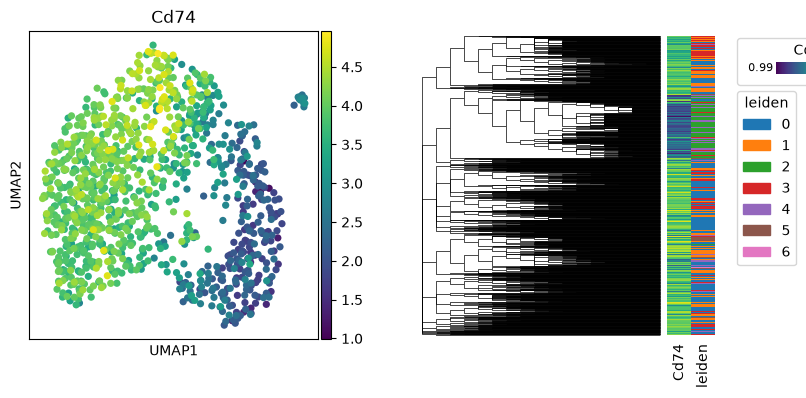

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
sc.pl.umap(tdata, color=["Cd74"], ax=axes[0], show=False)
py.pl.tree(tdata, keys=["Cd74", "leiden"], extend_branches=True, annotation_width=0.1, ax=axes[1])

#### Loading in tree Data from embryo days https://www.biorxiv.org/content/10.64898/2026.05.07.722278v1

In [86]:
dir_path = Path("/project/imoskowitz/kdreyer/public_datasets/005_Colgan2026/")

tdatas = {}
for file_path in dir_path.glob("E7.5*"): # Loading one day at a time because otherwise the file size will be overloaded
    tdatas[file_path.stem] = td.read_h5td(file_path)

### Getting familiar with the data

In [ ]:
tdatas
# stage is for date of data collection
# type contain 

{'E7.5-R2': TreeData object with n_obs × n_vars = 1838 × 78258
     obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree'
     var: 'gene_ids', 'mito', 'chromosome'
     obsm: 'X_scvi', 'X_umap', 'characters'
     obst: 'E7.5-R2-C1', 'E7.5-R2-C2', 'E7.5-R2-C3', 'E7.5-R2-C4', 'E7.5-R2-C5', 'E7.5-R2-C6',
 'E7.5-R1': TreeData object with n_obs × n_vars = 1342 × 78258
     obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree'
     var: 'gene_ids', 'mito', 'chromosome'
     obsm: 'X_scvi', 'X_umap', 'characters'
     obst: 'E7.5-R1-C1', 'E7.5-R1-C2',
 'E7.5-R3': TreeData object with n_obs × n_vars = 1468 × 78258
     obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clon

In [4]:
sample1 = tdatas['E7.5-R1']

In [75]:
for obs in sample1.obs:
    print(obs)
    print(sample1.obs[obs].unique() 
          ,"\n")
    if obs == 'tree':
        print(sample1.obs[obs].value_counts())

cell_subtype
['Extraembryonic mesoderm', 'Rostral ectoderm', 'Epiblast', 'Nascent mesoderm', 'Notochord', ..., 'Hematoendothelial progenitor', 'Definitive endoderm', 'Primordial germ cell', 'Visceral endoderm', 'Extraembryonic ectoderm']
Length: 11
Categories (11, object): ['Definitive endoderm', 'Epiblast', 'Extraembryonic ectoderm', 'Extraembryonic mesoderm', ..., 'Primitive streak', 'Primordial germ cell', 'Rostral ectoderm', 'Visceral endoderm'] 

capture
['E7.5-R1-T1']
Categories (1, object): ['E7.5-R1-T1'] 

embryo
['E7.5-R1']
Categories (1, object): ['E7.5-R1'] 

stage
['E7.5']
Categories (1, object): ['E7.5'] 

type
['donor', 'host']
Categories (2, object): ['donor', 'host'] 

total_counts
[64279. 44544. 52140. ... 52971. 52485. 65373.] 

pe_counts
[ 78.  87.  80.  92.  91.  77.  74.  83. 118. 105. 108.  66.  81. 109.
  73.  93.  97.  72.  64.  63.  52.  76. 116.  58.  47.  67. 117.  57.
  75. 106.  59. 100.  86.  68.  70.  44.  48.  89. 120.  56.  69.  49.
  61. 130. 121.  51.

In [35]:
sample1.obs["tree"].unique()
#sample1.obst['E7.5-R1-C2'].size()

['E7.5-R1-C1', 'E7.5-R1-C2', NaN]
Categories (2, object): ['E7.5-R1-C1', 'E7.5-R1-C2']

In [ ]:
py.pp.add_depth(sample1)

<PolarAxes: >

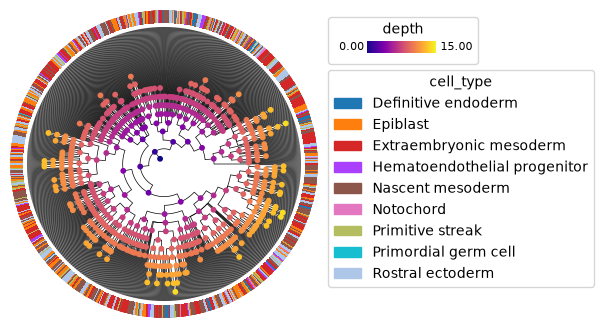

In [37]:
py.pl.branches(sample1, polar=True, extend_branches=True, tree="E7.5-R1-C1")
py.pl.nodes(sample1, color='depth', cmap="plasma")
py.pl.annotation(sample1, keys='cell_type', cmap='viridis', width=.1)

<PolarAxes: >

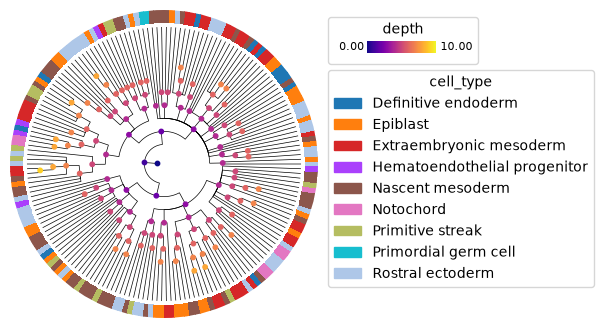

In [36]:
py.pl.branches(sample1, polar=True, extend_branches=True, tree="E7.5-R1-C2")
py.pl.nodes(sample1, color='depth', cmap="plasma")
py.pl.annotation(sample1, keys='cell_type', cmap='viridis', width=.1)

In [38]:
sample2 = tdatas['E7.5-R2']

In [ ]:
for sample in tdatas.values():
    print(sample.obs['tree'].value_counts())
    print(sample.obs['tree'].count()) #number of cells 
    for tree in sample.obst:
        print(sample.obst[tree].order()) # number of nodes per tree for that clone


tree
E7.5-R2-C1    757
E7.5-R2-C2    197
E7.5-R2-C3    162
E7.5-R2-C4    110
E7.5-R2-C5     47
E7.5-R2-C6     25
Name: count, dtype: int64
1298
1332
349
287
199
83
47
tree
E7.5-R1-C1    850
E7.5-R1-C2    182
Name: count, dtype: int64
1032
1484
303
tree
E7.5-R3-C1    1019
E7.5-R3-C2     189
E7.5-R3-C3     166
Name: count, dtype: int64
1374
1699
320
287
